# 配置环境，导入数据

In [77]:
source("/home/user/data2/lit/bin/lit_utils.R")
source("/home/user/data3/lit/project/sORFs/sORFs.utils.R")
lib_text()
lib_plot()

In [2]:
# 读入ISD计算结果
fread_c("../../processed/ISD/ISD.merged.txt") -> ISD
head(ISD)
nrow(ISD)

,Gene ID,Avg ISD,Protein Length
,<chr>,<chr>,<chr>
1,PB.30926.8:chr3:+|9|403:152:365|canonical|ATG,0.3283,106
2,PB.10103.45:chr12:-|8|1180:189:312|canonical|ATG,0.2596,50
3,PB.33715.13:chr4:+|9|1774:163:421|canonical|ATG,0.1449,122
4,PB.41685.227:chr6:-|23|3485:346:682|canonical|ATG,0.3577,156
5,PB.29979.15:chr3:+|32|5423:534:732|canonical|ATG,0.3163,75
6,PB.1187.14:chr1:-|19|3337:278:491|canonical|ATG,0.9544,102


[1] 12424

## 不同组别的数量

In [4]:
fread_c("../../processed/seve_list_compare/all_orfs_with_type.txt") -> all_orfs_with_type
nrow(all_orfs_with_type)
head(all_orfs_with_type)
table(all_orfs_with_type$type)
# fread_c("../../processed/evolution_para/kaks/cano_lnc_intergenic_noncano_sampled/all_kaks_results.summary.txt") -> kaks_1
fread_c("../../processed/evolution_para/kaks/cano_lnc_intergenic_noncano_sampled/all_kaks_results.txt") -> kaks_1
# fread_c("../../processed/evolution_para/kaks/noncano_sampled/all_kaks_results.summary.txt") -> kaks_2
fread_c("../../processed/evolution_para/kaks/noncano_sampled/all_kaks_results.txt") -> kaks_2
rbind(kaks_1,kaks_2) -> kaks_res

[1] 12420

,original_id,type,safe_id
,<chr>,<chr>,<chr>
1,146554953-146594515_193,Intergenic,146554953-146594515_193
2,190892429-191199240_2079,Intergenic,190892429-191199240_2079
3,68218080-68226652_24,Intergenic,68218080-68226652_24
4,80068757-80099536_136,Intergenic,80068757-80099536_136
5,91667782-91765898_373,Intergenic,91667782-91765898_373
6,140935010-140997951_3,Intergenic,140935010-140997951_3



            Canonical            Intergenic                lncRNA 
                 2500                  2500                  2420 
   Non-canonical-ORFs Non-canonical-Protein 
                 2500                  2500 

In [10]:
fread_c("../../processed/seve_list_compare/canonical_orfs.sample.2.5k.lt.150aa.txt") -> canonical_orfs
fread_c("../../processed/seve_list_compare/lnc_orfs.txt") -> lnc_orfs
fread_c("../../processed/seve_list_compare/non_cano_orfs.sample.2.5k.lt.150aa.txt") -> non_cano_orf
fread_c("../../processed/seve_list_compare/r1_m_minus_non_cano_orfs.sample.2.5k.lt.150aa.txt") -> r1_m_minus_non_cano_orfs
cols <- c("ORF_id","ORF_seq","CDS_seq")
rbind(canonical_orfs[,cols],lnc_orfs[,cols],non_cano_orf[,cols],r1_m_minus_non_cano_orfs[,cols]) -> all_orfs_detail

fread_c("../../processed/seve_list_compare/intergenic_orfs.sample.2.5k.lt.150aa.aa.tab") -> intergenic_id_prot_seq
fread_c("../../processed/seve_list_compare/intergenic_orfs.sample.2.5k.lt.150aa.tab") -> intergenic_id_cds_seq
merge(intergenic_id_prot_seq,intergenic_id_cds_seq,by="V1") %>% select(V1,V2.x,V2.y) -> intergenic_orf
colnames(intergenic_orf) <- c("ORF_id","ORF_seq","CDS_seq")
# head(intergenic_orf)
rbind(all_orfs_detail,intergenic_orf) -> all_orfs_detail_1
nrow(all_orfs_detail_1)
head(all_orfs_detail_1,1)%>% print()

[1] 12420

                                         ORF_id
1 PB.30926.8:chr3:+|9|403:152:365|canonical|ATG
                                                                 ORF_seq
1 MFTRAQVRRILQRVPGKQRFGIYRFLPFFFVLGGTMEWIMIKVRVGQETFYDVYRRKASERQYQRRLEDE
                                                                                                                                                                                                             CDS_seq
1 ATGTTCACCAGGGCCCAGGTGAGACGGATTCTGCAGCGGGTGCCCGGGAAGCAGCGATTTGGCATCTACCGGTTCCTGCCCTTCTTTTTTGTCCTGGGAGGAACGATGGAGTGGATCATGATTAAAGTGCGCGTGGGCCAGGAGACCTTCTATGATGTCTACCGTAGAAAAGCCTCAGAAAGACAGTATCAGAGAAGGCTGGAAGATGAA


In [6]:
merge(all_orfs_with_type,all_orfs_detail_1,by.x="original_id",by.y="ORF_id") ->all_orfs_detail_2

In [9]:
all_orfs_detail_2$ORF_length <- str_count(all_orfs_detail_2$ORF_seq)
head(all_orfs_detail_2,1) %>% print()

   original_id       type      safe_id
1 0-253742_649 Intergenic 0-253742_649
                                       ORF_seq
1 MQTLKVAQSALYLSSIRPRTSVDSNGCLVCSLSVLNETQAQCRL
                                                                                                                               CDS_seq
1 ATGCAGACTCTAAAGGTTGCACAGTCTGCACTATATCTGTCCTCAATTAGACCTAGGACCAGTGTCGACTCTAATGGTTGCCTAGTCTGCTCTCTATCTGTCCTCAATGAGACCCAGGCACAATGCAGACTC
  ORF_length
1         44


# 绘图设置

In [7]:
# # 设置颜色（可根据需要调整）
# type_colors <- c(
#     "Canonical" = "#E64B35",
#     "De novo human/hominoid genes" = "#4DBBD5",
#     "De novo" = "#4DBBD5",
#     "lncRNA" = "#00A087"
# )

In [11]:
# 需要 rlang >= 0.4，支持 {{ }} 注入

violin_plot <- function(df, x, y, fill = x,
                        type_colors = NULL,
                        y_breaks = c(0.01, 0.1, 1, 10, 100),
                        y_label = "NC ratio") {
  ggplot(df, aes(x = {{x}}, y = {{y}}, fill = {{fill}})) +
    geom_violin(alpha = 0.6, trim = FALSE,scale = "width",width=0.6) +
    geom_boxplot(width = 0.2, alpha = 0.8, outlier.shape = NA) +
    { if (!is.null(type_colors)) scale_fill_manual(values = type_colors) else scale_fill_brewer(palette = "Set2") } +
    labs(x = NULL, y = y_label) +
    guides(fill = "none") +
    theme_3(rotate = T)
}
# scale_y_log10(breaks = y_breaks, labels = sprintf("%.2f", y_breaks))

In [12]:
all_orfs_detail_2 -> all
table(all$type)


            Canonical            Intergenic                lncRNA 
                 2500                  2500                  2429 
   Non-canonical-ORFs Non-canonical-Protein 
                 2504                  2505 

In [13]:
LEVELS <- c("Intergenic","lncRNA","Non-canonical-ORFs","Non-canonical-Protein","Canonical")
all$type <- factor(all$type,levels=LEVELS)
type_names <- as.character(unique(all$type))
type_pairs <- combn(type_names, 2, simplify = FALSE)
type_pairs

[[1]]
[1] "Intergenic" "lncRNA"    

[[2]]
[1] "Intergenic"         "Non-canonical-ORFs"

[[3]]
[1] "Intergenic"            "Non-canonical-Protein"

[[4]]
[1] "Intergenic" "Canonical" 

[[5]]
[1] "lncRNA"             "Non-canonical-ORFs"

[[6]]
[1] "lncRNA"                "Non-canonical-Protein"

[[7]]
[1] "lncRNA"    "Canonical"

[[8]]
[1] "Non-canonical-ORFs"    "Non-canonical-Protein"

[[9]]
[1] "Non-canonical-ORFs" "Canonical"         

[[10]]
[1] "Non-canonical-Protein" "Canonical"

# 长度比较

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


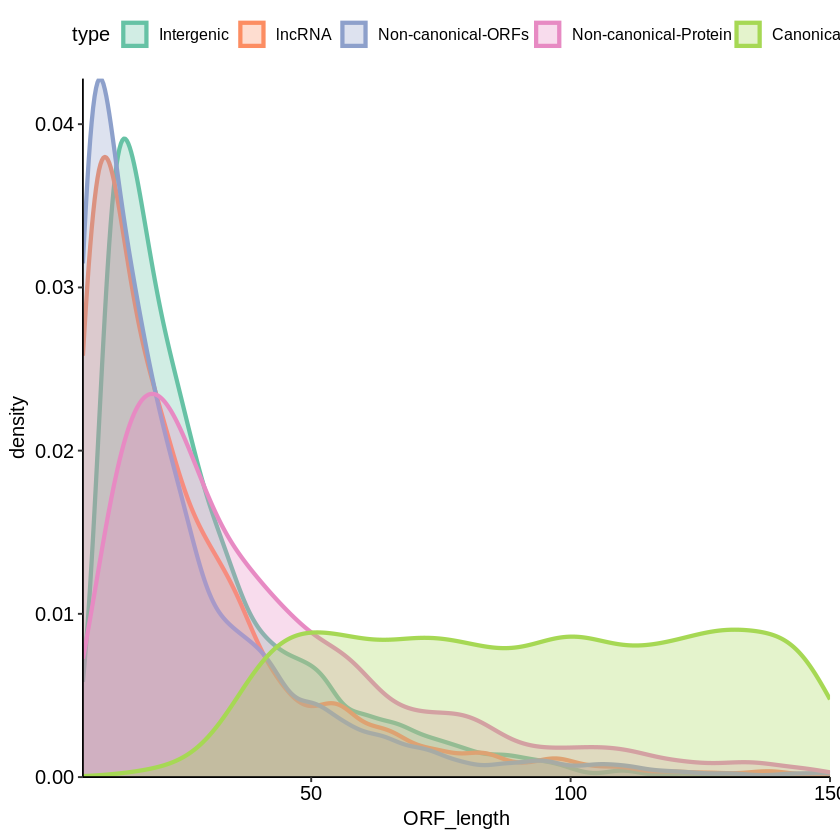

In [14]:
ggplot(all, aes(x = ORF_length, 
                             color = type, fill = type)) +
    geom_density(alpha = 0.3, size = 1.2) +
theme_3()+
scale_fill_brewer(palette = "Set2")+
scale_color_brewer(palette = "Set2")+
scale_y_continuous(expand = c(0, 0)) +
scale_x_continuous(expand = c(0, 0)) 

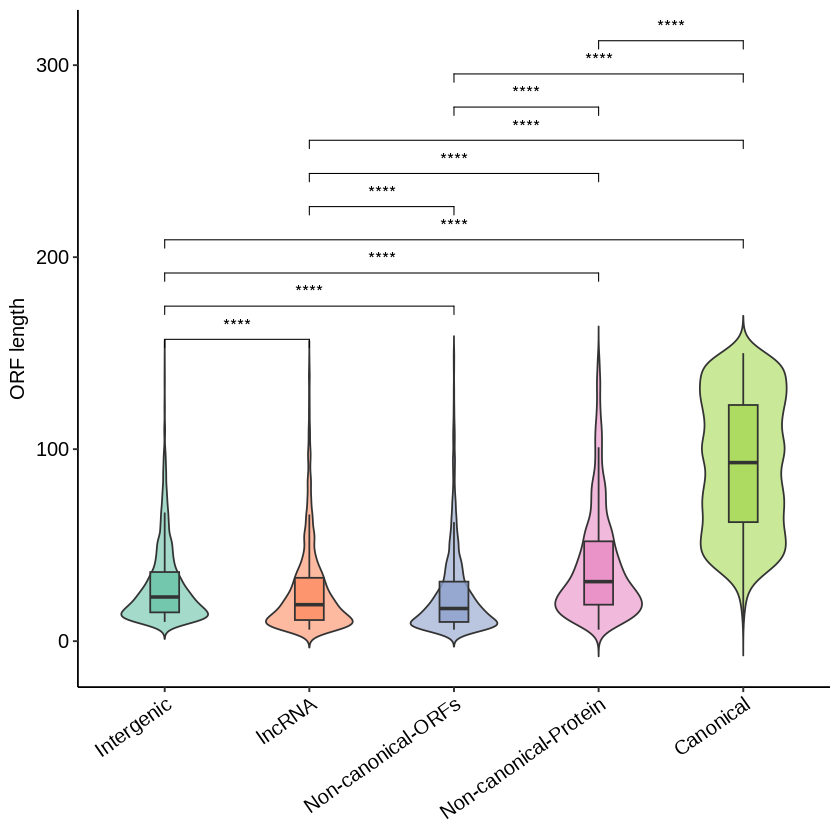

In [22]:
p <- violin_plot(all , x = type, y = ORF_length, fill = type,y_label = "ORF length")
compare(p, type_pairs) -> p_orf_length
p_orf_length

In [18]:
all %>% group_by(type) %>% summarise(min(ORF_length),max(ORF_length),median(ORF_length),mean(ORF_length))

type,min(ORF_length),max(ORF_length),median(ORF_length),mean(ORF_length)
<fct>,<int>,<int>,<dbl>,<dbl>
Intergenic,10,148,23,29.26280
lncRNA,6,147,19,26.57637
Non-canonical-ORFs,6,150,17,24.79832
Non-canonical-Protein,6,150,31,39.78323
Canonical,12,150,93,92.16920


In [19]:
# 统一拉到10以上确实会改变数值
all %>% filter(ORF_length>=10) %>% group_by(type) %>% summarise(min(ORF_length),max(ORF_length),median(ORF_length),mean(ORF_length))

type,min(ORF_length),max(ORF_length),median(ORF_length),mean(ORF_length)
<fct>,<int>,<int>,<dbl>,<dbl>
Intergenic,10,148,23,29.26280
lncRNA,10,147,23,31.04165
Non-canonical-ORFs,10,150,22,30.10902
Non-canonical-Protein,10,150,32,40.91232
Canonical,12,150,93,92.16920


# GC含量

In [23]:
# ===== 1. 计算GC含量 =====
calculate_gc_content <- function(seq) {
    # 转换为大写
    seq_upper <- toupper(seq)
    # 计算G和C的数量
    gc_count <- str_count(seq_upper, "[GC]")
    # 计算总碱基数（排除N）
    total_count <- str_count(seq_upper, "[ATCG]")
    # 计算GC百分比
    gc_percent <- gc_count / total_count
    return(gc_percent)
}

# 为all数据框添加GC含量列
all <- all %>%
    mutate(GC_content = sapply(CDS_seq, calculate_gc_content))

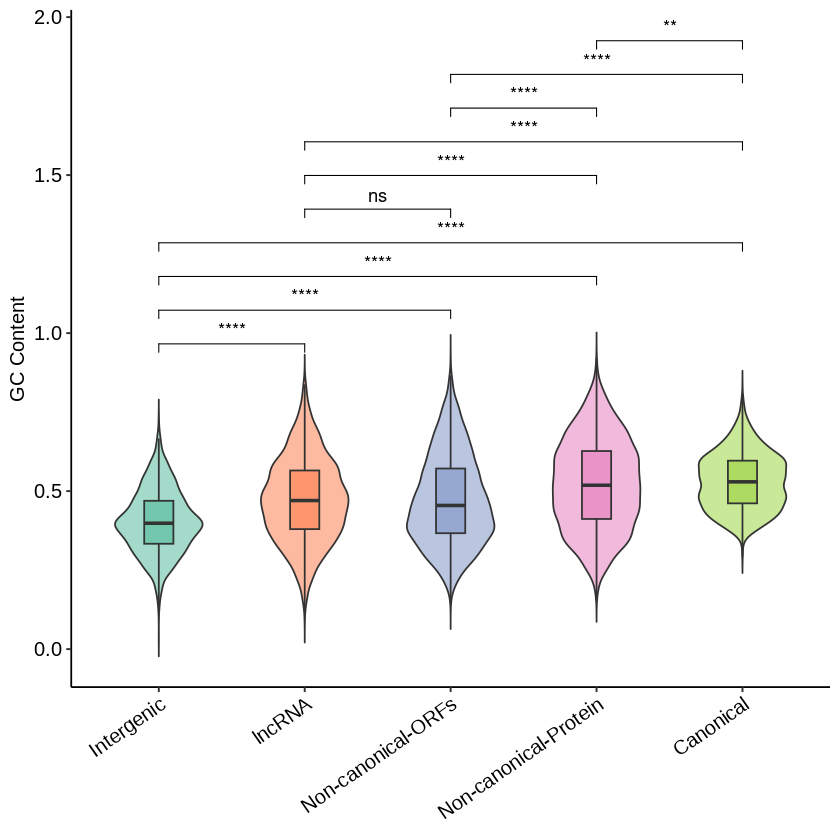

In [24]:
p1 <- violin_plot(all , x = type, y = GC_content, fill = type,y_label = "GC Content")
compare(p1, type_pairs) -> p_gc
p_gc
# ggsave(filename = out_name_1("NC_ratio"),height = 6,width = 3)

# C端疏水性

In [25]:
library(Peptides)
nrow(all)
all <- all %>%
      mutate(Last15A = substr(ORF_seq,start = ORF_length-14, stop=ORF_length)) %>% 
mutate(Hydrophobicity_full = hydrophobicity(ORF_seq, scale = "Miyazawa")) %>% 
mutate(Hydrophobicity_Last15A = hydrophobicity(Last15A, scale = "Miyazawa")) -> all
head(all[,c("Last15A","Hydrophobicity_full","Hydrophobicity_Last15A")])

[1] 12438

,Last15A,Hydrophobicity_full,Hydrophobicity_Last15A
,<chr>,<dbl>,<dbl>
1,CSLSVLNETQAQCRL,5.666818,5.745333
2,VVSTFECSDTTPLTI,6.161765,5.784667
3,SEKRDIITSFNLYMC,6.010893,5.912000
4,PRRVCIELKLVKCMT,6.610000,6.140667
5,ASRVAGTTGARHHTS,5.883226,4.852667
6,KVKIFYPKTCFFAIF,6.019333,6.518000


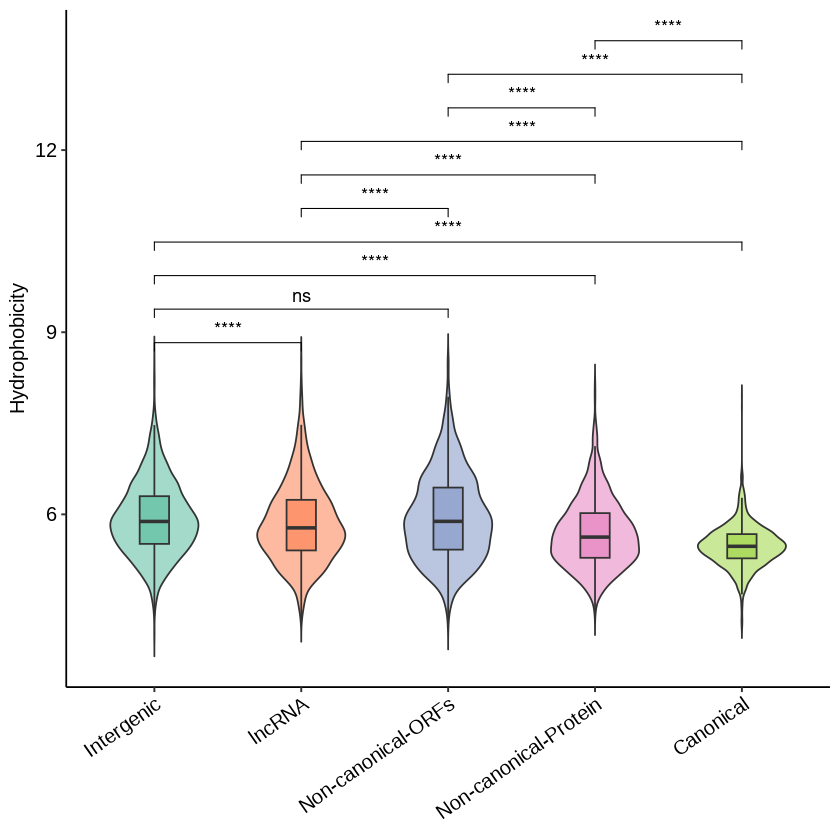

In [26]:
p1 <- violin_plot(all, x = type, y = Hydrophobicity_full, fill = type, y_label = "Hydrophobicity")
compare(p1, type_pairs) -> p_hydro
p_hydro

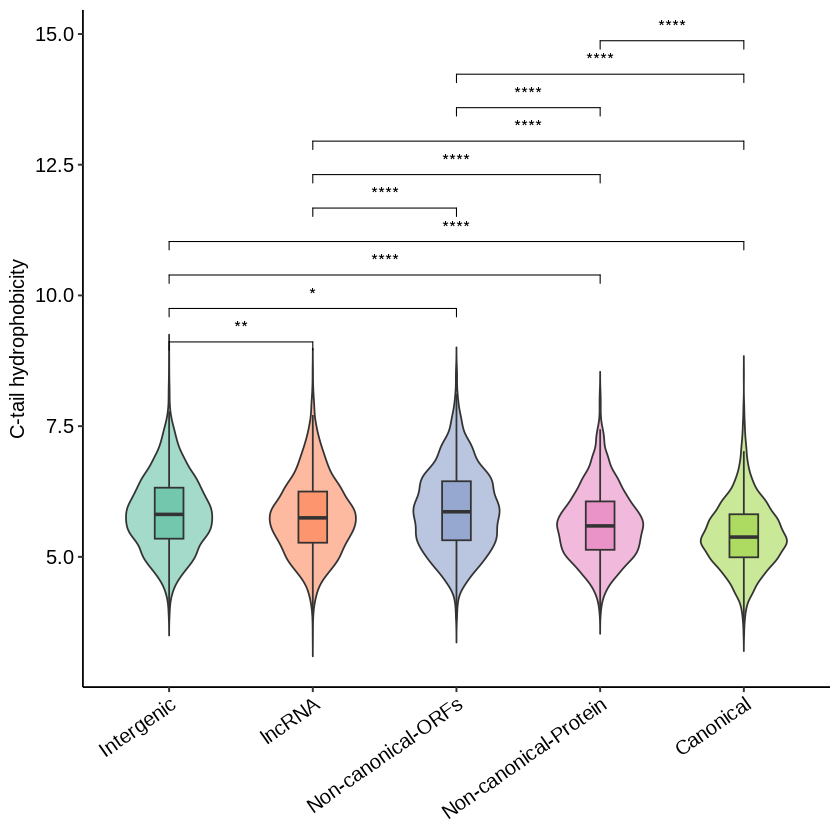

In [27]:
p1 <- violin_plot(all, x = type, y = Hydrophobicity_Last15A, fill = type, y_label = "C-tail hydrophobicity")
compare(p1, type_pairs)-> p_hydro_c_tail
p_hydro_c_tail

# ISD

In [29]:
head(all,1)
nrow(all)
head(ISD,1)
colnames(ISD) <- c("ORF_id","Avg_ISD","Protein_length")
ISD$Avg_ISD <- as.numeric(ISD$Avg_ISD)
merge(all,ISD,by.x="original_id",by.y="ORF_id") -> all_add_ISD
head(all_add_ISD,1)
colnames(all_add_ISD)
nrow(all_add_ISD)
table(all_add_ISD$type)
LEVELS <- c("Intergenic","lncRNA","Non-canonical-ORFs","Non-canonical-Protein","Canonical")
all_add_ISD$type <- factor(all_add_ISD$type,levels=LEVELS)

,original_id,type,safe_id,ORF_seq,CDS_seq,ORF_length,GC_content,Last15A,Hydrophobicity_full,Hydrophobicity_Last15A
,<chr>,<fct>,<chr>,<chr>,<chr>,<int>,<dbl>,<chr>,<dbl>,<dbl>
1,0-253742_649,Intergenic,0-253742_649,MQTLKVAQSALYLSSIRPRTSVDSNGCLVCSLSVLNETQAQCRL,ATGCAGACTCTAAAGGTTGCACAGTCTGCACTATATCTGTCCTCAATTAGACCTAGGACCAGTGTCGACTCTAATGGTTGCCTAGTCTGCTCTCTATCTGTCCTCAATGAGACCCAGGCACAATGCAGACTC,44,0.4772727,CSLSVLNETQAQCRL,5.666818,5.745333


[1] 12438

,ORF_id,Avg_ISD,Protein_length
,<chr>,<dbl>,<chr>
1,PB.30926.8:chr3:+|9|403:152:365|canonical|ATG,0.3283,106


,original_id,type,safe_id,ORF_seq,CDS_seq,ORF_length,GC_content,Last15A,Hydrophobicity_full,Hydrophobicity_Last15A,Avg_ISD,Protein_length
,<chr>,<fct>,<chr>,<chr>,<chr>,<int>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
1,0-253742_649,Intergenic,0-253742_649,MQTLKVAQSALYLSSIRPRTSVDSNGCLVCSLSVLNETQAQCRL,ATGCAGACTCTAAAGGTTGCACAGTCTGCACTATATCTGTCCTCAATTAGACCTAGGACCAGTGTCGACTCTAATGGTTGCCTAGTCTGCTCTCTATCTGTCCTCAATGAGACCCAGGCACAATGCAGACTC,44,0.4772727,CSLSVLNETQAQCRL,5.666818,5.745333,0.273,51


[1] "original_id"            "type"                   "safe_id"               
 [4] "ORF_seq"                "CDS_seq"                "ORF_length"            
 [7] "GC_content"             "Last15A"                "Hydrophobicity_full"   
[10] "Hydrophobicity_Last15A" "Avg_ISD"                "Protein_length"

[1] 10627


           Intergenic                lncRNA    Non-canonical-ORFs 
                 2500                  1804                  1939 
Non-canonical-Protein             Canonical 
                 1892                  2492 

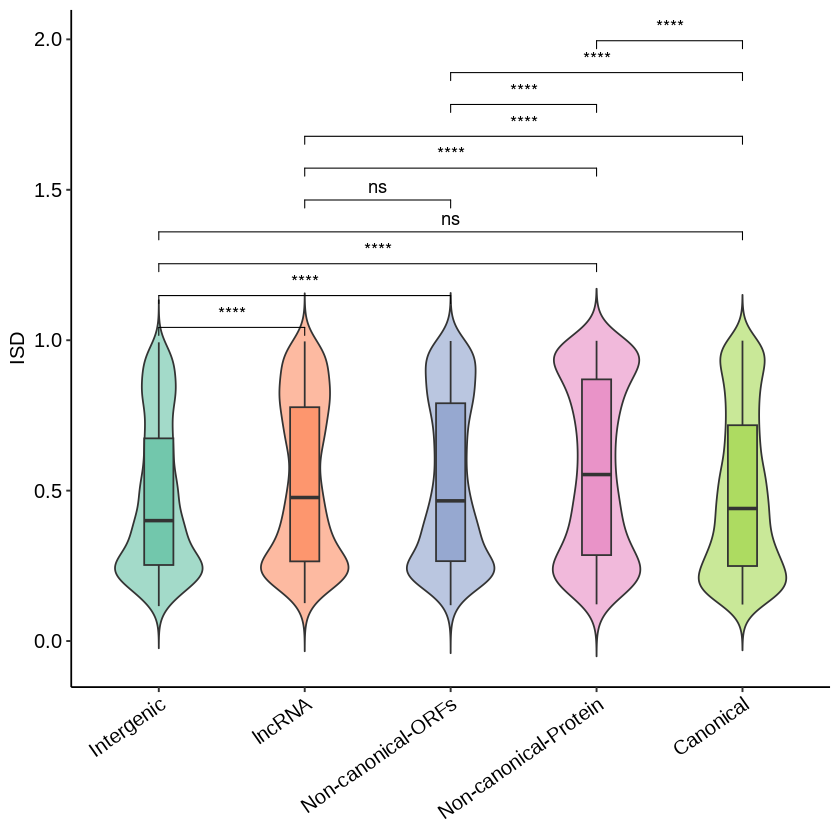

In [30]:
p1 <- violin_plot(all_add_ISD, x = type, y = Avg_ISD, fill = type, y_label = "ISD")
compare(p1, type_pairs)-> p_isd
p_isd

In [31]:
all_add_ISD %>% group_by(type) %>% summarise(mean_1=mean(Avg_ISD))

type,mean_1
<fct>,<dbl>
Intergenic,0.4709980
lncRNA,0.5259106
Non-canonical-ORFs,0.5270292
Non-canonical-Protein,0.5718348
Canonical,0.4921501


In [32]:
head(all_add_ISD$Avg_ISD)

[1] 0.2730 0.5075 0.2002 0.6112 0.7614 0.1649

# 其他比较（不涉及intergenic）

In [33]:
cols <- c("ORF_id","ORF_seq","CDS_seq","N","C","RPF_RPKM","FL_TPM")
rbind(canonical_orfs[,cols],lnc_orfs[,cols],r1_m_minus_non_cano_orfs[,cols],non_cano_orf[,cols]) -> all_orfs_detail
merge(distinct(all_orfs_with_type,original_id,type),all_orfs_detail,by.x="original_id",by.y="ORF_id") -> all_1
nrow(all_1)
table(all_1$type)

[1] 9938


            Canonical                lncRNA    Non-canonical-ORFs 
                 2500                  2429                  2504 
Non-canonical-Protein 
                 2505 

In [34]:
LEVELS <- c("lncRNA","Non-canonical-ORFs","Non-canonical-Protein","Canonical")
all_1$type <- factor(all_1$type,levels=LEVELS)
type_names <- as.character(unique(all_1$type))
type_pairs <- combn(type_names, 2, simplify = FALSE)
type_pairs

[[1]]
[1] "lncRNA"             "Non-canonical-ORFs"

[[2]]
[1] "lncRNA"                "Non-canonical-Protein"

[[3]]
[1] "lncRNA"    "Canonical"

[[4]]
[1] "Non-canonical-ORFs"    "Non-canonical-Protein"

[[5]]
[1] "Non-canonical-ORFs" "Canonical"         

[[6]]
[1] "Non-canonical-Protein" "Canonical"

## 翻译效率

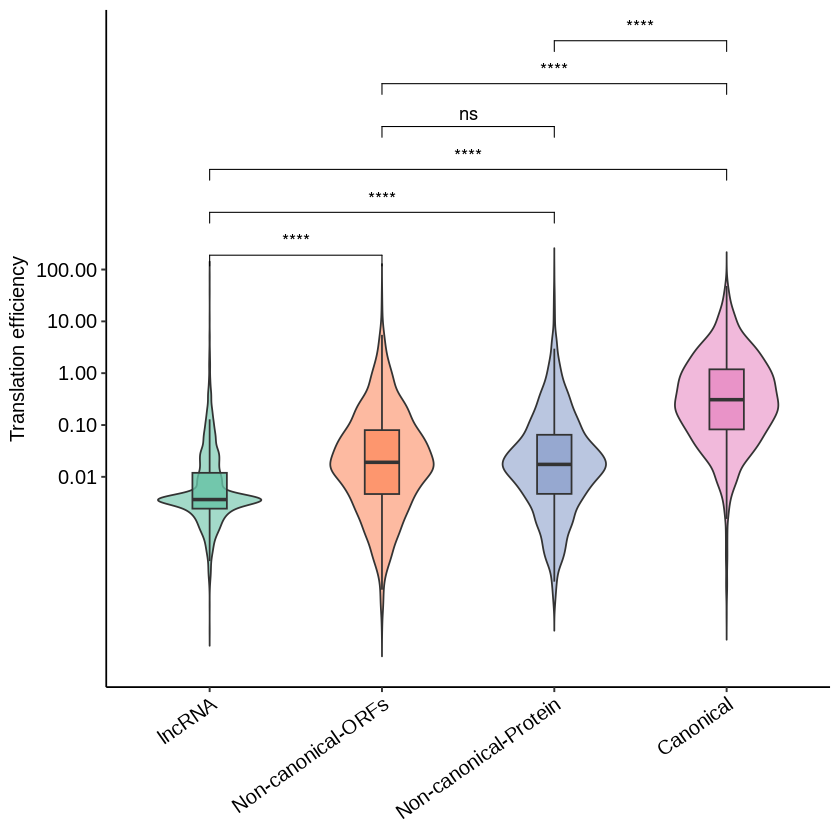

In [35]:
all_1 <- all_1 %>%
    mutate(TE = (RPF_RPKM+0.001)/(FL_TPM+0.001))
y_breaks = c(0.01, 0.1, 1, 10, 100)
p1 <- violin_plot(all_1 , x = type, y = TE, fill = type,y_label = "Translation efficiency")+
scale_y_log10(breaks = y_breaks, labels = sprintf("%.2f", y_breaks))
compare(p1, type_pairs) -> p_te
p_te

## 出核水平

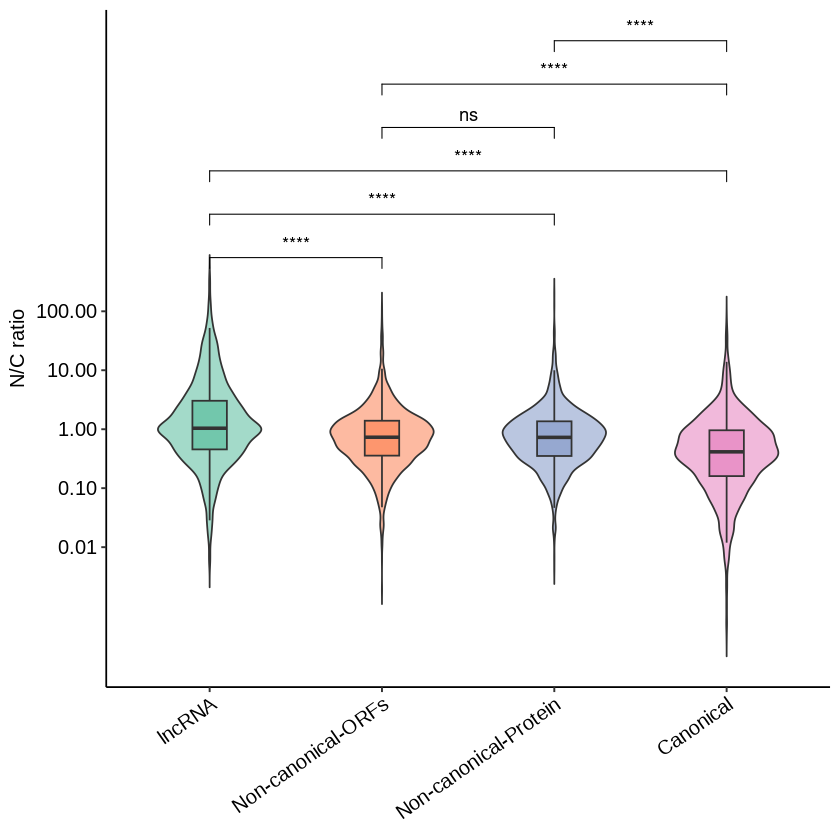

In [36]:
all_1 <- all_1 %>%
    mutate(NC_ratio = (N+0.001)/(C+0.001))
y_breaks = c(0.01, 0.1, 1, 10, 100)
p1 <- violin_plot(all_1, x = type, y = NC_ratio, fill = type,y_label = "N/C ratio")+
scale_y_log10(breaks = y_breaks, labels = sprintf("%.2f", y_breaks))
compare(p1, type_pairs) -> p_nc_ratio
p_nc_ratio

## 转录

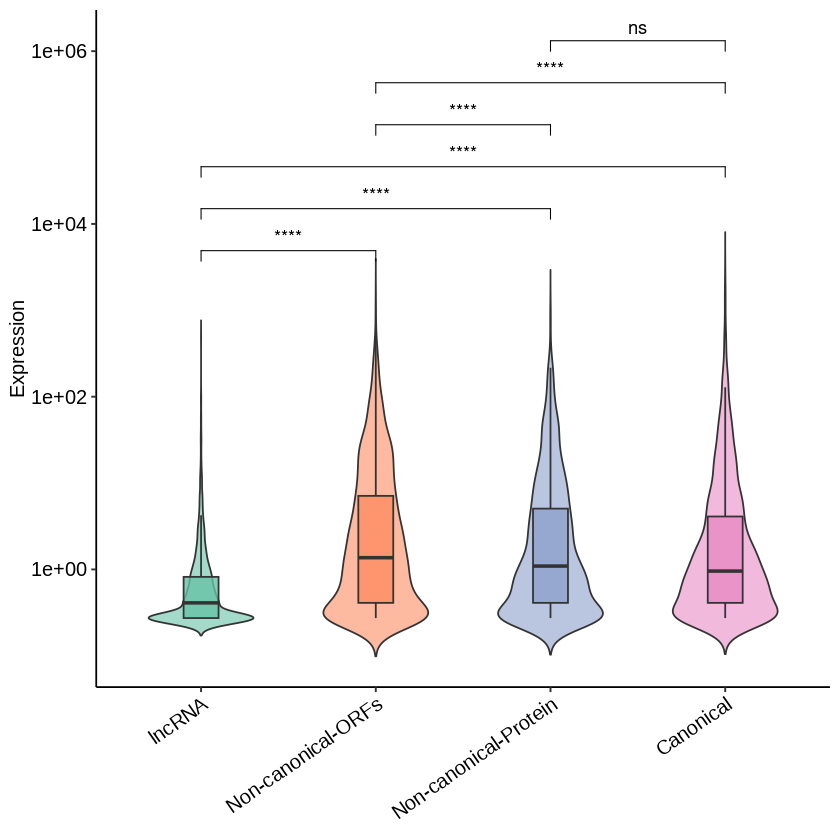

In [51]:
violin_plot(all_1, x = type, y = FL_TPM, fill = type,y_label = "Expression")+
scale_y_log10() -> p
compare(p, type_pairs) -> p_expression
p_expression

# 将除了进化参数之外的结果导出

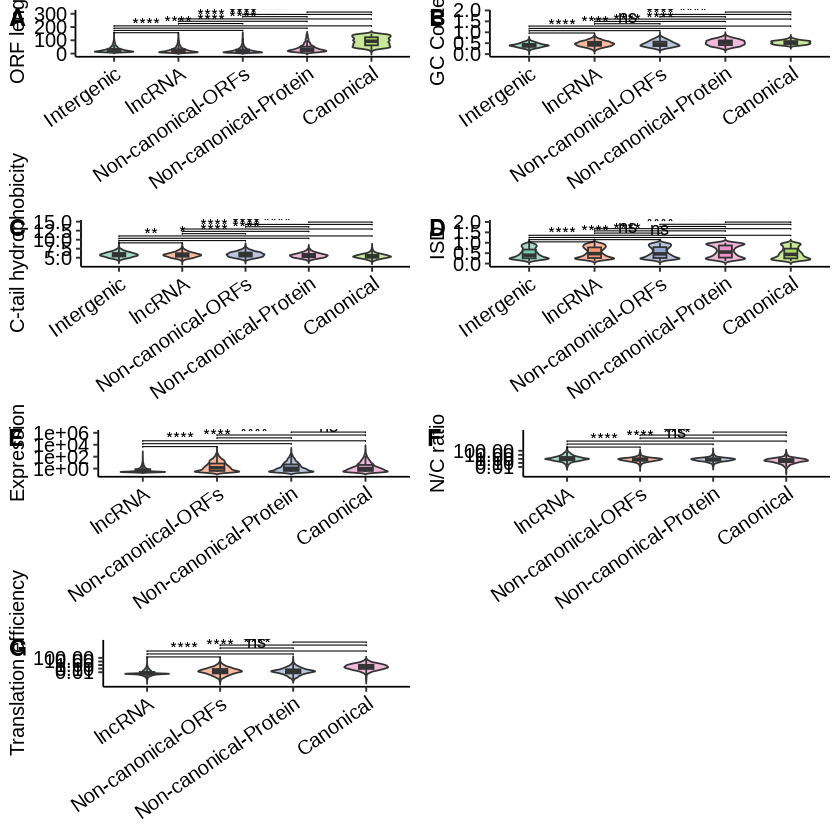

In [55]:
output_path <- "../../figures/for_graduation_paper_compare_20251121"
combined_plot <- plot_grid(p_orf_length, p_gc, p_hydro_c_tail,p_isd,p_expression,p_nc_ratio,p_te,
                            ncol = 2, nrow = 4, labels = "AUTO")
combined_plot
ggsave(filename = o("combined_plot.pdf"), plot = combined_plot, height = 16, width = 10)

## 统计比较

In [49]:
custom_stat <- function(data, col) {
  data %>% 
    group_by(type) %>% 
    summarise(
      min = min({{ col }}, na.rm = TRUE),
      max = max({{ col }}, na.rm = TRUE),
      median = median({{ col }}, na.rm = TRUE),
      mean = mean({{ col }}, na.rm = TRUE)
    ) %>% arrange(median)
}

# 使用方式
print("ORF_length comparison")
custom_stat(all, ORF_length)
print("GC_content comparison")
custom_stat(all,GC_content )
print("Hydrophobicity_Last15A comparison")
custom_stat(all,Hydrophobicity_Last15A )
print("Avg_ISD comparison")
custom_stat(all_add_ISD,Avg_ISD )
print("TE comparison")
custom_stat(all_1,TE )
print("NC_ratio comparison")
custom_stat(all_1,NC_ratio )
print("Expression comparison")
custom_stat(all_1,FL_TPM )

[1] "ORF_length comparison"


type,min,max,median,mean
<fct>,<int>,<int>,<dbl>,<dbl>
Non-canonical-ORFs,6,150,17,24.79832
lncRNA,6,147,19,26.57637
Intergenic,10,148,23,29.26280
Non-canonical-Protein,6,150,31,39.78323
Canonical,12,150,93,92.16920


[1] "GC_content comparison"


type,min,max,median,mean
<fct>,<dbl>,<dbl>,<dbl>,<dbl>
Intergenic,0.03333333,0.7333333,0.3982611,0.4039322
Non-canonical-ORFs,0.14285714,0.9147287,0.4545455,0.4720520
lncRNA,0.09523810,0.8571429,0.4700855,0.4724462
Non-canonical-Protein,0.16666667,0.9215686,0.5185185,0.5208190
Canonical,0.29100529,0.8305085,0.5293030,0.5306975


[1] "Hydrophobicity_Last15A comparison"


...

type,min,max,median,mean
<fct>,<dbl>,<dbl>,<dbl>,<dbl>
lncRNA,1.080721e-05,72.36470,0.003644952,0.0886476
Non-canonical-Protein,3.246238e-05,85.37900,0.017370932,0.2648187
Non-canonical-ORFs,1.137494e-05,38.51184,0.019063693,0.2119970
Canonical,2.217091e-05,70.16898,0.308007464,1.5304153


[1] "NC_ratio comparison"


type,min,max,median,mean
<fct>,<dbl>,<dbl>,<dbl>,<dbl>
Canonical,0.0002995762,83.30793,0.4136154,1.125118
Non-canonical-Protein,0.0042000044,201.28547,0.7274416,1.500440
Non-canonical-ORFs,0.0019253835,116.36380,0.7312808,1.539360
lncRNA,0.0046675031,401.91390,1.0394127,5.574876


[1] "Expression comparison"


type,min,max,median,mean
<fct>,<dbl>,<dbl>,<dbl>,<dbl>
lncRNA,0.273352,480.6903,0.410029,1.565277
Canonical,0.273352,3074.5320,0.956734,15.431403
Non-canonical-Protein,0.273352,1108.3076,1.093410,11.484568
Non-canonical-ORFs,0.273352,1419.3827,1.366762,14.117116


# kaks

In [80]:
head(all_orfs_with_type,1)
nrow(all_orfs_with_type)
n_distinct(all_orfs_with_type$safe_id)
head(kaks_res,1)
nrow(kaks_res)
n_distinct(kaks_res$ORF)

,original_id,type,safe_id
,<chr>,<chr>,<chr>
1,146554953-146594515_193,Intergenic,146554953-146594515_193


[1] 12420

[1] 12411

,ORF,Species_pair,Ka,Ks,Ka/Ks,S-Substitutions,N-Substitutions
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,PB.23209.2__chr2__-__88__1650__1155__1530__canonical__ATG.prot,hg38-ailMel1,0.0755257,0.277506,0.272159,24,18


[1] 244656

[1] 8132

In [81]:
kaks_res %>% filter(!is.na(Ks) & !is.na(Ka))  %>% filter(Ks>=0.2) -> kaks_res_with_ks
kaks_res_with_ks %>% group_by(ORF) %>% summarize(median_ka_ks=median(Ka/Ks),median_ks=median(Ks)) -> kaks_res_1
head(kaks_res_1)

ORF,median_ka_ks,median_ks
<chr>,<dbl>,<dbl>
100330264-100335562_9.prot,0.3672922,0.2664425
100464613-100475666_91.prot,0.2487607,0.3166085
100542021-100586648_342.prot,0.2549983,0.2962730
100829944-100907173_61.prot,0.2327227,0.2507920
101228876-101280104_327.prot,0.3862658,0.3344760
101228876-101280104_49.prot,0.2147138,0.2751870


In [82]:
gsub(pattern = ".prot","",kaks_res_1$ORF) -> kaks_res_1$ORF
merge(kaks_res_1,all_orfs_with_type,by.x="ORF",by.y="safe_id") -> all_orfs_with_type_kaks
nrow(all_orfs_with_type_kaks)
head(all_orfs_with_type_kaks)
all_orfs_with_type_kaks %>% group_by(type) %>% summarise(median_kaks=median(median_ka_ks),n=n(),median_ks=median(median_ks),mean_kaks=mean(median_ka_ks))

[1] 3968

,ORF,median_ka_ks,median_ks,original_id,type
,<chr>,<dbl>,<dbl>,<chr>,<chr>
1,100330264-100335562_9,0.3672922,0.2664425,100330264-100335562_9,Intergenic
2,100464613-100475666_91,0.2487607,0.3166085,100464613-100475666_91,Intergenic
3,100542021-100586648_342,0.2549983,0.2962730,100542021-100586648_342,Intergenic
4,100829944-100907173_61,0.2327227,0.2507920,100829944-100907173_61,Intergenic
5,101228876-101280104_327,0.3862658,0.3344760,101228876-101280104_327,Intergenic
6,101228876-101280104_49,0.2147138,0.2751870,101228876-101280104_49,Intergenic


type,median_kaks,n,median_ks,mean_kaks
<chr>,<dbl>,<int>,<dbl>,<dbl>
Canonical,0.1369545,1681,0.3292200,0.1674603
Intergenic,0.2629669,715,0.2803995,0.3163958
Non-canonical-ORFs,0.3757298,1,0.2345590,0.3757298
Non-canonical-Protein,0.3054159,794,0.2816190,0.3570141
lncRNA,0.2610363,777,0.3056960,0.3121079


Warning message:
“Groups with fewer than two datapoints have been dropped.
ℹ Set `drop = FALSE` to consider such groups for position adjustment purposes.”


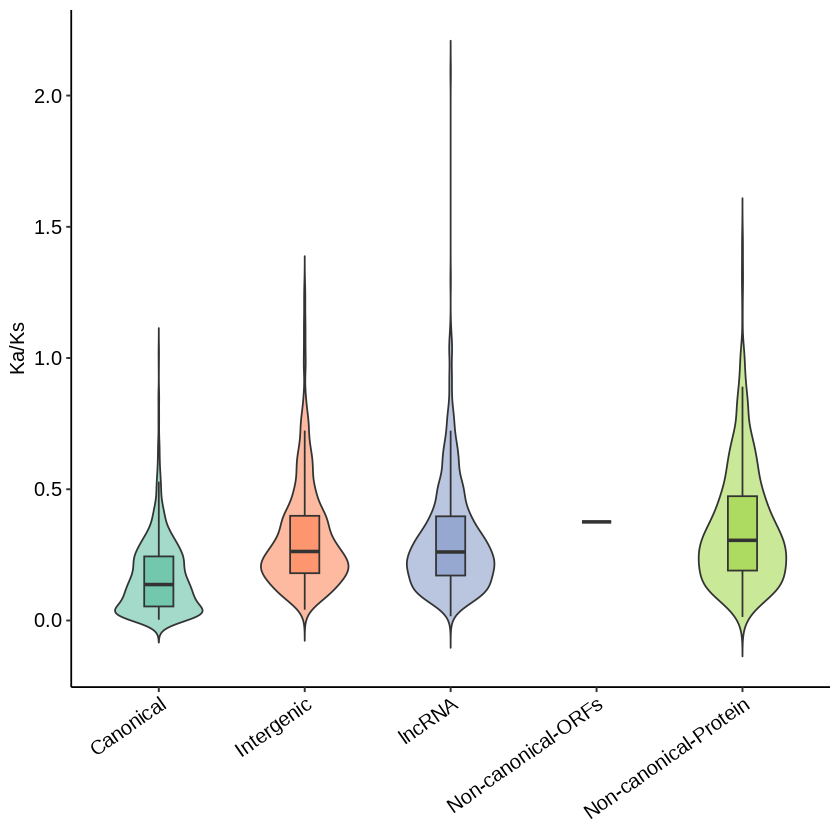

In [83]:
# scale_y_log10(breaks = y_breaks, labels = sprintf("%.2f", y_breaks))
violin_plot_1(all_orfs_with_type_kaks, x = type, y = median_ka_ks, fill = type,y_label = "Ka/Ks")

# pnps

In [67]:
fread_c("../../processed/pnps/orf_syn_nonsyn.strict.tsv") -> orf_syn_nonsyn
head(orf_syn_nonsyn,1)
tail(orf_syn_nonsyn,1)

,ORF_ID,syn_sites,nonsyn_sites
,<chr>,<int>,<int>
1,99309590-99464377_203,0,1


,ORF_ID,syn_sites,nonsyn_sites
,<chr>,<int>,<int>
12411,PB.15699.1:chr15:+|11|491:215:392|noncoding|ACG,0,3


In [70]:
merge(all_orfs_with_type,orf_syn_nonsyn,by.x="original_id",by="ORF_ID") -> all_orfs_pnps
all_orfs_pnps %>% group_by(type) %>% 
summarise(syn_sites_sum=sum(syn_sites),nonsyn_sites_sum=sum(nonsyn_sites)) %>% mutate(nonsyn_sites_sum/syn_sites_sum*1/2)

type,syn_sites_sum,nonsyn_sites_sum,nonsyn_sites_sum/syn_sites_sum * 1/2
<chr>,<int>,<int>,<dbl>
Canonical,3207,4585,0.7148425
Intergenic,1153,3238,1.4041631
Non-canonical-ORFs,836,1931,1.1549043
Non-canonical-Protein,1493,3301,1.1054923
lncRNA,953,2288,1.2004197


In [85]:
all_orfs_pnps %>% filter(syn_sites >0 & nonsyn_sites >0)  -> all_orfs_pnps_filtered
nrow(all_orfs_pnps_filtered)
all_orfs_pnps_filtered %>% mutate(pnps_raw=nonsyn_sites/syn_sites*1/2) -> all_orfs_pnps_filtered

[1] 3351

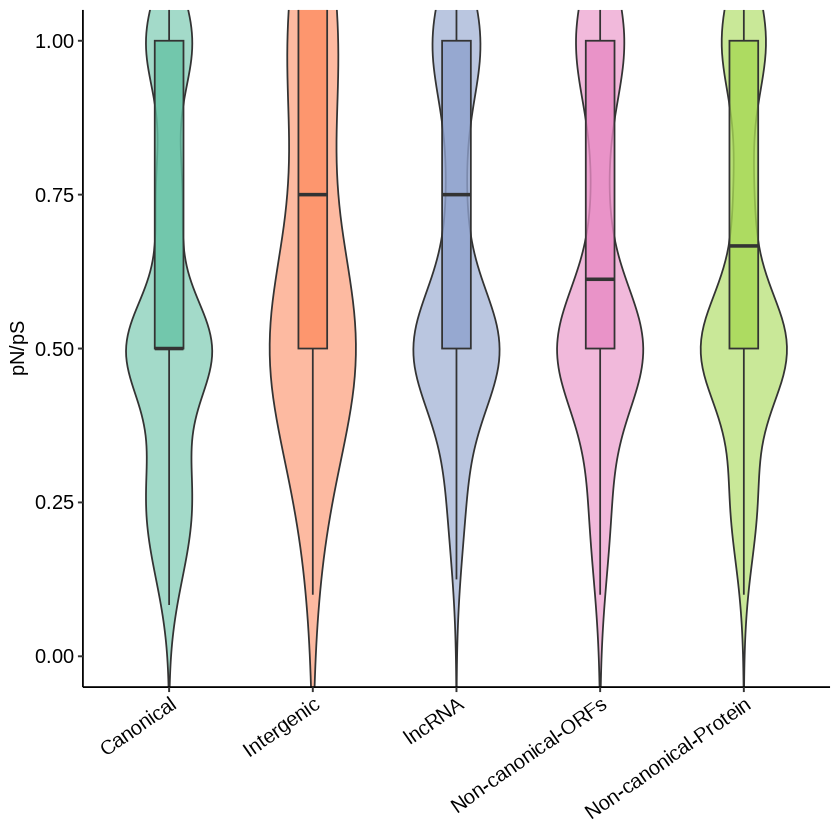

In [87]:
violin_plot_1(all_orfs_pnps_filtered, x = type, y = pnps_raw, fill = type,y_label = "pN/pS")+
coord_cartesian(ylim = c(0, 1))

In [66]:
# all_orfs_with_type %>% filter(type=="Non-canonical-ORFs") -> Non_canonical_ORFs
# nrow(Non_canonical_ORFs)
# merge(Non_canonical_ORFs,orf_syn_nonsyn,by.x="original_id",by="ORF_ID")